# Credit Card Defaults Prediction & Stress Testing

This project analyzes a dataset of 30,000 credit card clients from a retail bank in Taiwan, capturing customer profiles, credit limits, and detailed repayment behavior from April to September. Using 23 explanatory variables, including demographics, payment history, bill amounts, and prior repayments. We model the likelihood of default.

The objective is to translate predicted probabilities of default into actionable credit strategies: optimizing approval decisions, quantifying value at risk from bad approvals, and identifying lost opportunity from declined but creditworthy customers.

## Data Loading

In [1]:
%pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# features and targets
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# # variable information
# print(default_of_credit_card_clients.variables)

# combine into a single dataframe
df = pd.concat([X, y], axis=1)
df.columns = list(X.columns) + ['default_payment_next_month']

In [4]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.shape
# 30000 rows with 24 variables

(30000, 24)

In [ ]:
# missing values?
df.isnull().sum()

In [ ]:
# count defaults vs. non-defaults
df['default_payment_next_month'].value_counts()
# show percentage of defaults vs non defaults
df['default_payment_next_month'].value_counts(normalize=True)

,proportion
default_payment_next_month,
0,0.7788
1,0.2212


Preliminary analysis shows that the dataset is imbalanced, with non-defaults accounting for approximately 78% and defaults around 22%. This imbalance could bias the logistic regression model, as the majority class may dominate the learning process. We will take this into consideration during modeling.

## Feature Importance

We have 23 features in the dataset, since they are not too many, we will include them all regardless of their predictive power. However, it is still fun to check out the feature importance. We are using Random Forest Classifier here.

In [ ]:
# identity X variables and the target

target = 'default_payment_next_month'
X = df.drop(columns=[target])
y = df[target]

# split training, testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2026)

In [ ]:
# train with RF
rf_model = RandomForestClassifier(random_state=2026)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=2026)

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

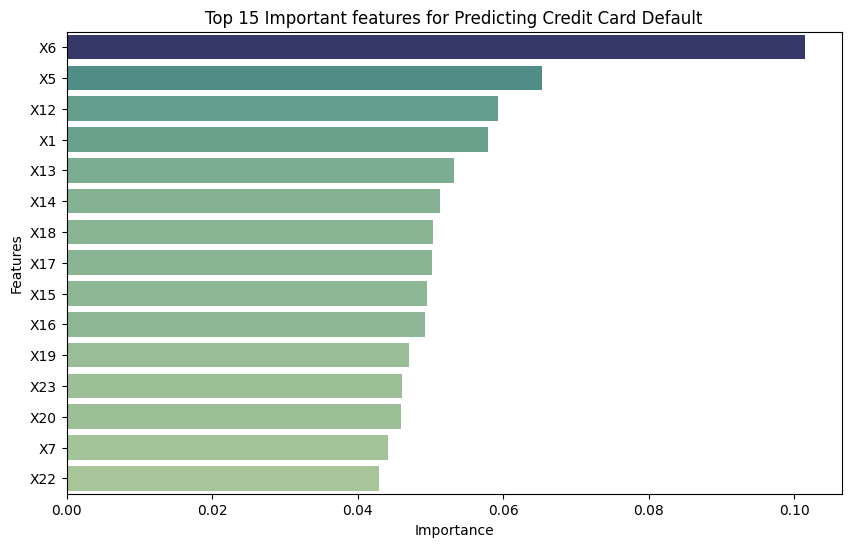

In [ ]:
top_n = 15 # plot the top 15 importance features

# Prepare a DataFrame for Seaborn
feat_df = pd.DataFrame({
    "Feature": feature_importances.index[:top_n],
    "Importance": feature_importances.values[:top_n]
})

# Add a column for hue based on importance (for gradient)
feat_df["Importance_for_color"] = feat_df["Importance"]

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_df,
    hue="Importance_for_color",
    dodge=False,
    palette="crest",
    legend=False
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title(f"Top {top_n} Important features for Predicting Credit Card Default")
plt.show()

`X6` is the payment status for the current month. We are not suprised that it was seen as the most importance feature to predict the status for next month payment.

## Model Development

We will begin with Logistic Regression as a baseline model to establish a simple and interpretable benchmark. Next, we will use a Decision Tree to capture potential non-linear relationships between the features and the target variable. Finally, we will apply an XGBoost model, which leverages a collection of decision trees, to further enhance predictive performance and capture more complex patterns in the data.

### Logistic Regression


#### Data Preparation (Scaling)

In [5]:
target = 'default_payment_next_month'

X = df.drop(columns=[target])
y = df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2026, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# fit LR
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

### Decision Tree

In [6]:
# fit dt model with the usual X_train, y_train, i.e., no scaling needed

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=2026
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=2026)

### XGBoost

In [ ]:
# fit xgb with the usual training & testing set

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=2026)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Model Validation
We are going use AUC and confusion matrix to compare the model performances.

In [8]:
# write an evaluation function to calculate auc and confusion matrix

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(f"AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [9]:
# plot confusion matrix

def plot_cm(y_true, y_pred, model_name):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize row-wise (percentages)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Turn into DataFrame
    df_cm = pd.DataFrame(cm_percent, index=['good', 'bad'], columns=['good', 'bad'])

    # Figure settings
    figsize = (6,5)
    fontsize = 12

    # Create heatmap with diverging colors
    fig = plt.figure(figsize=figsize)
    heatmap = sns.heatmap(df_cm, annot=True, fmt='.2f')


    # Tweak tick labels
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)

    # Labels
    plt.ylabel('True Label', fontsize=fontsize)
    plt.xlabel('Predicted Label', fontsize=fontsize)
    plt.title(f'Confusion Matrix for {model_name}', fontsize=fontsize)

    plt.show()

### Logistic Regression

In [ ]:
# LR
evaluate_model("Logistic Regression", log_model, X_test_scaled, y_test)


===== Logistic Regression =====
AUC: 0.7399

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      7009
           1       0.39      0.67      0.49      1991

    accuracy                           0.69      9000
   macro avg       0.63      0.68      0.63      9000
weighted avg       0.77      0.69      0.71      9000



In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

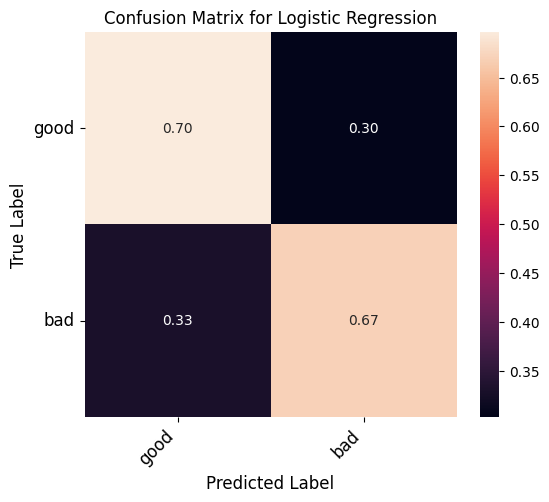

In [ ]:
plot_cm(y_test, y_pred_log, "Logistic Regression")

### Decision Tree

In [ ]:
# DT
evaluate_model("Decision Tree", dt_model, X_test, y_test)


===== Decision Tree =====
AUC: 0.7729

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79      7009
           1       0.40      0.71      0.51      1991

    accuracy                           0.70      9000
   macro avg       0.65      0.71      0.65      9000
weighted avg       0.79      0.70      0.73      9000



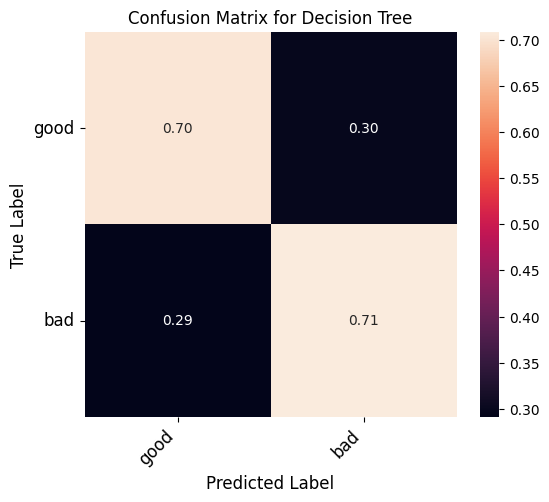

In [10]:
y_pred_dt = dt_model.predict(X_test)
plot_cm(y_test, y_pred_dt, "Decision Tree")

### XGBoost

In [ ]:
# XGBoost
evaluate_model("XGBoost", xgb_model, X_test, y_test)


===== XGBoost =====
AUC: 0.7667

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      7009
           1       0.63      0.38      0.47      1991

    accuracy                           0.81      9000
   macro avg       0.74      0.66      0.68      9000
weighted avg       0.80      0.81      0.80      9000



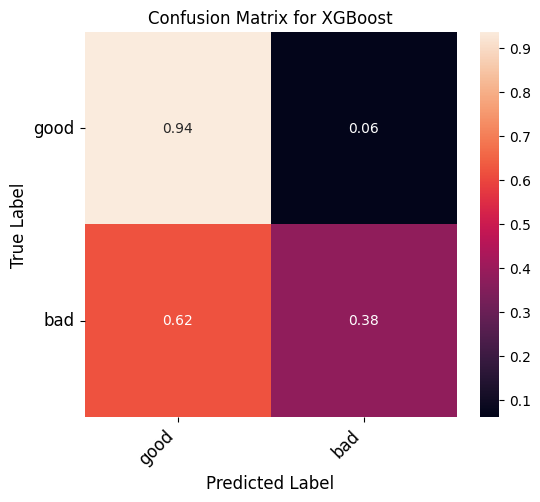

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
plot_cm(y_test, y_pred_xgb, "XGBoost")

We noticed the unusual high false negative proportion in the XGB prediction, and would like to fine tune the parameters. In credit risk, false negatives are more dangerous than false positives. So we want the model to:
- Catch more defaulters i.e., increase recall for class 1
- Keep precision reasonably high → don’t flag too many good customers
- this is optional, increase the AUC score for model's overall ability to distinguish defaulters vs non-defaulters.

## Optimization: XGB Parameters Tuning

In [ ]:
# Grid search for basic parameters
# scale_pos_weight handles data imbalance and pay more attetion to the defaulters

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=2026
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'scale_pos_weight': [sum(y_train==0)/sum(y_train==1)]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall',    # optimize recall for class 1 - defaulters
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best params: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': 3.5209903121636166, 'subsample': 1}


In [ ]:
xgb_model_opt = XGBClassifier(
    eval_metric='logloss',
    colsample_bytree = 1,
    learning_rate = 0.5,
    max_depth = 3,
    n_estimators = 300,
    scale_pos_weight = sum(y_train==0)/sum(y_train==1),
    subsample=1,
    random_state=2026)
xgb_model_opt.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
evaluate_model("XGBoost", xgb_model_opt, X_test, y_test)


===== XGBoost =====
AUC: 0.7621

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      7009
           1       0.44      0.63      0.52      1991

    accuracy                           0.74      9000
   macro avg       0.66      0.70      0.67      9000
weighted avg       0.78      0.74      0.75      9000



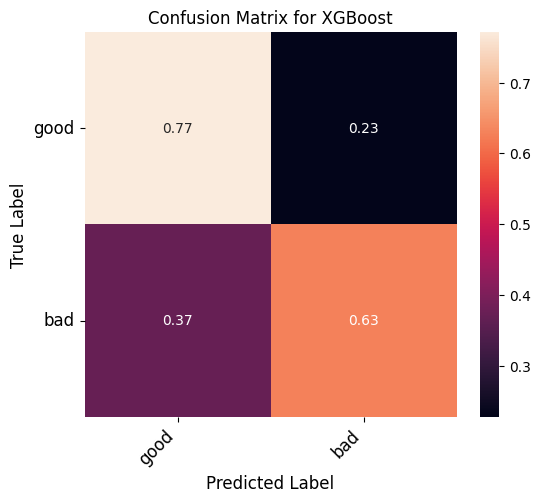

In [ ]:
y_pred_xgb_opt = xgb_model_opt.predict(X_test)
plot_cm(y_test, y_pred_xgb_opt, "XGBoost")

We now reduced the false negative rate from approximately 63% to 37%. Although the true negative rate decreased to 77%, we were able to identify about 63% of defaulters, compared to only 38% before.

From the comparison, the Decision Tree model achieves the lowest false negative rate (approximately 29%) and the highest AUC score (~0.773). We will use this model to predict credit card defaults for clients.

# Credit Card Strategy

## Risk thresholds

Now we finished model development. We want to assign customers into risk tiers based on the predicted probability of default. Customers in different tiers will trigger credit card review actions accordingly.

We will define the risk thresholds as following:

| Risk Tier    | Probability of Default | Action                                      |
| ------------ | ---------------------- | ------------------------------------------- |
| Low risk     | < 20%             | Approve automatically                       |
| Medium risk  | 20-50%              | Require second review / manual verification |
| High risk    | 50-70%               | Offer lower credit limit          |
| Extreme risk | > 70%               | Decline automatically                       |


The target `default_payment_next_month` for 30,000 customers are known. We will use decision trees to estimate the probability of default for each customer. By comparing predictions to the actual outcomes, we can quantify:
- **Risk**: How many approved customers actually defaulted, and hence how much loan value is at risk?

- **Lost Opportunity**: how many declined customers would have been safe?

In [ ]:
# fitting DT
df['pred_prob'] = dt_model.predict_proba(X)[:,1]

conditions = [
    df['pred_prob'] < 0.20,
    (df['pred_prob'] >= 0.20) & (df['pred_prob'] < 0.50),
    (df['pred_prob'] >= 0.50) & (df['pred_prob'] < 0.70),
    df['pred_prob'] >= 0.7
]

actions = ['Approve', 'Second Review', 'Limit', 'Decline']

df['action'] = np.select(conditions, actions, default='Unknown')

In [ ]:
df.head() # check now there's a column called `action` appended to the table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X17,X18,X19,X20,X21,X22,X23,default_payment_next_month,pred_prob,action
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,0.885664,Decline
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,0.505627,Limit
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,0.387787,Second Review
3,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,0.383092,Second Review
4,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,0.193592,Approve


In [ ]:
# Group by action

summary = df.groupby('action').agg(
    total_customers=('default_payment_next_month', 'count'),
    actual_defaults=('default_payment_next_month', 'sum'),   # number of real defaults
    actual_non_defaults=('default_payment_next_month', lambda x: (x==0).sum())
).reset_index()

# Calculate percentages
summary['default_rate'] = summary['actual_defaults'] / summary['total_customers'] * 100
summary['safe_rate'] = summary['actual_non_defaults'] / summary['total_customers'] * 100

summary

,action,total_customers,actual_defaults,actual_non_defaults,default_rate,safe_rate
0,Approve,280,18,262,6.428571,93.571429
1,Decline,4799,2966,1833,61.804543,38.195457
2,Limit,6722,1674,5048,24.903303,75.096697
3,Second Review,18199,1978,16221,10.868729,89.131271


If we plot the default rate by action, we can see the default rate is highest in the `decline` action, which is what we would like to see. The second highest is `Offering lower credit limit`, and then `Second review`, the lowest default rate is in `approve` action. This result aligns with the ordering of the risk thresholds, as expected.

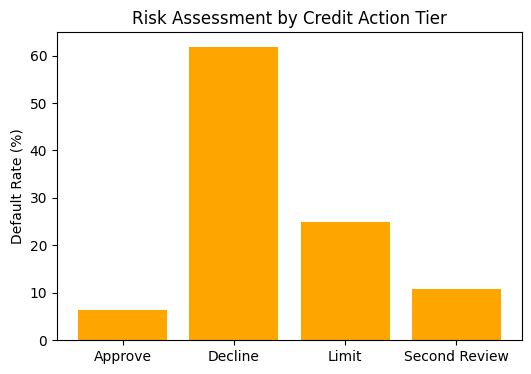

In [ ]:
# Bar plot of default rate per action
plt.figure(figsize=(6,4))
plt.bar(summary['action'], summary['default_rate'], color='orange')
plt.ylabel('Default Rate (%)')
plt.title('Risk Assessment by Credit Action Tier')
plt.show()

## Risk

Under the current risk thresholds, 280 customers were approved, of which 18 were actual defaulters and 262 were good customers, leading to a safety rate of approximately 93.6%. The estimated value at risk is around $1,160,000.





In [ ]:
# calculate credit balance associated with action = approve and actual defaulters

approved_defaults = df[
    (df['action'] == 'Approve') &
    (df['default_payment_next_month'] == 1)
]

value_at_risk = approved_defaults['X1'].sum()
print(f"Value at risk: {value_at_risk}")

# Proportion of risk relative to total approved exposure
total_approved_limit = df[df['action'] == 'Approve']['X1'].sum()
risk_percentage = value_at_risk / total_approved_limit * 100
print(f"Proportion of approved credit at risk: {risk_percentage:.2f}%")

Value at risk: 1160000
Proportion of approved credit at risk: 4.87%


## Lost Opportunity

In this section, we want to quantify the lost opportunity by looking into the customers who were declined despite being non-defaulters. We declined 4799 customers in total, among which, 1833 were non-defaulters. The opporunity was estimated to be $184,546,000.

In [ ]:
# calculate credit balance associated with action = decline and actual non-defaulters

declined_non_defaults = df[
    (df['action'] == 'Decline') &
    (df['default_payment_next_month'] == 0)
]

lost_opportunity = declined_non_defaults['X1'].sum()
print(f"Lost opportunity:{lost_opportunity}")

Lost opportunity:184546000


## Scorecard

We can also convert the predicted probability of default into a scorecard framework, segmenting customers into score bands aligned with risk tiers and linking each band to specific business actions. I will briefly demonstrate an approach here:

In [ ]:
df['score'] = (1 - df['pred_prob']) * 1000

In [ ]:
df.head() # you can see there's a column `score` for each customer

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X18,X19,X20,X21,X22,X23,default_payment_next_month,pred_prob,action,score
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,0.885664,Decline,114.335647
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,0.505627,Limit,494.373082
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,0.387787,Second Review,612.212701
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,0.383092,Second Review,616.908495
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,0.193592,Approve,806.407702


In [ ]:
# now we translate the risk thresholds to score range

conditions = [
    df['score'] >= 850,
    (df['score'] >= 700) & (df['score'] < 850),
    (df['score'] >= 500) & (df['score'] < 700),
    df['score'] < 500
]

bands = ['Excellent', 'Good', 'Fair', 'Poor']

df['score_band'] = np.select(conditions, bands, default='Unknown')

In [ ]:
# map the decision

decision_map = {
    'Excellent': 'Approve',
    'Good': 'Approve',
    'Fair': 'Second Review',
    'Poor': 'Decline'
}

df['final_decision'] = df['score_band'].map(decision_map)

In [ ]:
df.head() # check

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X20,X21,X22,X23,default_payment_next_month,pred_prob,action,score,score_band,final_decision
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,0.885664,Decline,114.335647,Poor,Decline
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,0.505627,Limit,494.373082,Poor,Decline
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,0.387787,Second Review,612.212701,Fair,Second Review
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,0.383092,Second Review,616.908495,Fair,Second Review
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,0.193592,Approve,806.407702,Good,Approve


### Default at Risk
If we applied the scorecard based on the above demonstration, and approve credit lines if a customer is in `Excellent` or `Good` standing, the defaults and value at risk for each score band was illustrated as following:

In [ ]:
scorecard_summary = df.groupby('score_band').agg(
    total=('default_payment_next_month', 'count'),
    defaults=('default_payment_next_month', 'sum')
).reset_index()

scorecard_summary['default_rate'] = scorecard_summary['defaults'] / scorecard_summary['total']
scorecard_summary

,score_band,total,defaults,default_rate
0,Excellent,67,5,0.074627
1,Fair,7439,1107,0.148810
2,Good,10973,884,0.080561
3,Poor,11521,4640,0.402743


In [ ]:
# value at risk by score band

var_by_band = (
    df[df['default_payment_next_month'] == 1]  # filter only defaults
    .groupby('score_band')['X1']
    .sum()
    .reset_index(name='VaR')
)
var_by_band

,score_band,VaR
0,Excellent,620000
1,Fair,119720000
2,Good,186357680
3,Poor,556710000


# Stress Testing

## Addtional features

Before stress testing, we developed some signals as following:

- **Credit unitilization** = bill amount / total credit balance

  High utilization could mean more financial stress.

- **Payment ratio** = payment amount / bill amount

  This signals the customer's ability to pay.

- **Avg Deliquency score** = mean(PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6)

  This calculates the average length of deliquency for the customer in the 6 months.

- **Balance growth** = bill amount (in September) - bill amount (in September)

  Detects if a customer's debt is increasing / decreaing from the past 6 months. Positive value indicates that the customer is spending more and not paying enough; negative value means the customer spending less or paying down the debt, suggesting healthy financial behaviour.





## Scenarios

Let's consider some stressed scenarios:

1. **Inflation**: when encountering inflation, prices are higher and the purchasing value of money will fall. It likely causes customers rely more heavily on the credit card, and slow the repayment behaviour. We set the credit utilization to be up about 20%, payment amount down 10% and takes about 1 month longer for a customer to fully clear a balance.

2. **Recession**: If we think about a severe recession, we think of high unemployment rate, liquidity crisis, less cash and hence deliquency rate peaks.
We can set bill amount increase by 40%, payment amount decrease by 20%, and takes a customer 2 mmonths to fully clear a previous balance.

We will demonstrate the case of inflation.

In [11]:
df_stress = df.copy()

In [12]:
df_stress["credit_utilization_baseline"] = df_stress["X12"]/df_stress["X1"] # current credit utilization

In [13]:
df_stress["credit_utilization_stressed"] = df_stress["credit_utilization_baseline"] * 1.2

In [14]:
df_stress.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X17,X18,X19,X20,X21,X22,X23,default_payment_next_month,credit_utilization_baseline,credit_utilization_stressed
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,0.195650,0.234780
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,0.022350,0.026820
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,0.324878,0.389853
3,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,0.939800,1.127760
4,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,0.172340,0.206808


In [15]:
df_stress["X12"] = df_stress["credit_utilization_stressed"] * df_stress["X1"] # current bill amount under stressed

In [16]:
df_stress["X18"] *= 0.8
df_stress["X19"] *= 0.8 # payments for current + last month under stressed

In [17]:
for col in ["X6", "X7", "X8"]:
    df_stress[col] += 1    # payment status under stessed - takes 1 month longer to fully repay

In [18]:
df["pay_ratio_stress"] = df_stress["X18"] / df_stress["X12"]

In [19]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X16,X17,X18,X19,X20,X21,X22,X23,default_payment_next_month,pay_ratio_stress
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,689,0,0,0,0,1,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,0.000000
2,90000,2,2,2,34,0,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,0.034611
3,50000,2,2,1,37,0,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,0.028375
4,50000,1,2,1,57,-1,0,-1,0,0,...,19146,19131,2000,36681,10000,9000,689,679,0,0.154733


In [20]:
# train/test split

target = 'default_payment_next_month'

X_stress = df_stress.drop(columns=[target])
y_stress = df_stress[target]

X_train_stress, X_test_stress, y_train_stress, y_test_stress = train_test_split(
    X_stress, y_stress, test_size=0.3, random_state=2026, stratify=y_stress
)

In [21]:

dt_model_stress = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=2026
)
dt_model_stress.fit(X_train_stress, y_train_stress)

DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=2026)

## DT Model under Stressed Scenarios

In [22]:
predict_y_stress = dt_model_stress.predict(X_test_stress)

In [23]:
evaluate_model("Decision Tree", dt_model_stress, X_test_stress, y_test_stress)


===== Decision Tree =====
AUC: 0.7291

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      7009
           1       0.42      0.62      0.50      1991

    accuracy                           0.73      9000
   macro avg       0.65      0.69      0.66      9000
weighted avg       0.78      0.73      0.75      9000



The Decision Tree model under the stressed scenario correctly identified 76% of good customers and 62% of defaulters, compared to the baseline model, which captured 70% of good customers and 71% of defaulters. While the stressed model performs better at identifying good customers, it misses some defaulters, misclassifying them as low-risk. As shown in the following bar graph, the baseline model predicts higher PD values overall, whereas the stressed model somewhat unexpectedly predicted 568 additional non-defaulters as low-risk.

In [24]:
num_good = np.sum(predict_y_stress == 0)
print(f"Model predicted good customers under stressed scenario: {num_good}")
num_bad = np.sum(predict_y_stress == 1)
print(f"Model predicted bad customers under stressed scenario: {num_bad}")

Model predicted good customers under stressed scenario: 6076
Model predicted bad customers under stressed scenario: 2924


In [30]:
num_good = np.sum(y_pred_dt == 0)
print(f"Model predicted good customers baseline: {num_good}")
num_bad = np.sum(y_pred_dt == 1)
print(f"Model predicted bad customers baseline: {num_bad}")

Model predicted good customers baseline: 5508
Model predicted bad customers baseline: 3492


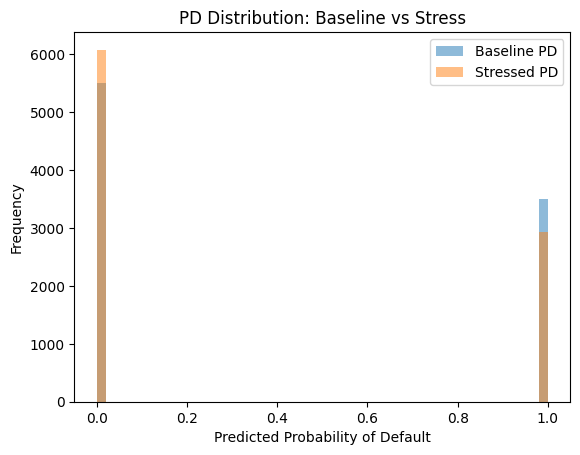

In [33]:
plt.figure()

plt.hist(y_pred_dt, bins=50, alpha=0.5, label="Baseline PD")
plt.hist(predict_y_stress, bins=50, alpha=0.5, label="Stressed PD")
# plt.hist(y_test_stress, bins=50, alpha=0.5, label="Actual PD")

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Frequency")
plt.title("PD Distribution: Baseline vs Stress")
plt.legend()

plt.show()